In [1]:
# -------------------------------
# STEP X: Decision Tree (Diabetes Dataset)
# -------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt


In [5]:
# -------------------------------
# STEP 1: Load dataset
# -------------------------------
from google.colab import files
# Step 2: Load dataset
print("Please upload your csv file")
uploaded = files.upload()

# Step 3: Read uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(df.head())

Please upload your csv file


Saving diabetes.csv to diabetes.csv
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


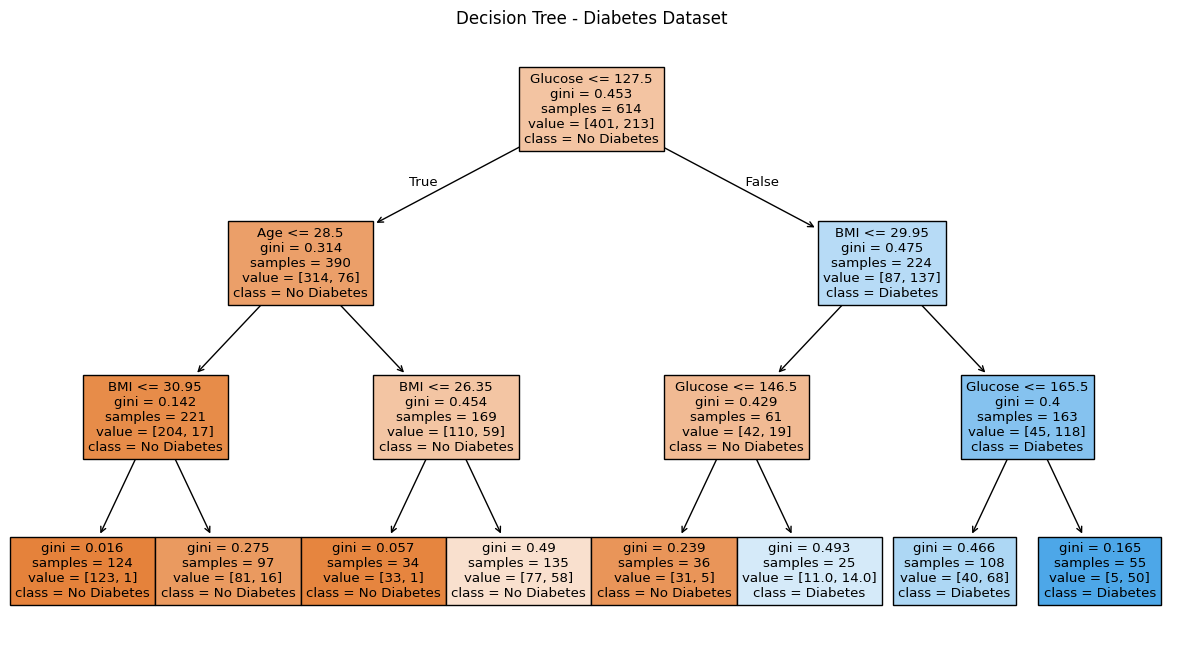

In [10]:
# -------------------------------
# STEP 2: Define features and target
# -------------------------------
X = df.drop("Outcome", axis=1)   # predictors
y = df["Outcome"]                # target (0 = no diabetes, 1 = diabetes)


# -------------------------------
# STEP 3: Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -------------------------------
# STEP 4: Train Decision Tree
# -------------------------------
# You can control complexity using max_depth
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)

tree_model.fit(X_train, y_train)


# -------------------------------
# STEP 5: Visualize Tree
# -------------------------------
plt.figure(figsize=(15,8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)

plt.title("Decision Tree - Diabetes Dataset")
plt.show()

In [11]:
# -------------------------------
# STEP 6: Extract Node Rules
# -------------------------------
rules = export_text(tree_model, feature_names=list(X.columns))

print("\nDecision Tree Rules:\n")
print(rules)


Decision Tree Rules:

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 30.95
|   |   |   |--- class: 0
|   |   |--- BMI >  30.95
|   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 146.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  146.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 165.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  165.50
|   |   |   |--- class: 1

